Installation et imports


In [ ]:
!pip install torch torchvision matplotlib numpy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Convolution 2D manuelle avec Numpy


In [ ]:
# Cellule 2: Implémentation manuelle de la convolution 2D
def conv2d_manual(image, kernel, stride=1, padding=0):
    h_k, w_k = kernel.shape
    h_img, w_img = image.shape

    if padding > 0:
        image = np.pad(image, padding, mode='constant')
        h_img, w_img = image.shape

    h_out = (h_img - h_k) // stride + 1
    w_out = (w_img - w_k) // stride + 1

    output = np.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            region = image[i*stride:i*stride+h_k, j*stride:j*stride+w_k]
            output[i, j] = np.sum(region * kernel)

    return output

# Exemple de test
image_test = np.array([[1,2,3,4,5],
                       [6,7,8,9,10],
                       [11,12,13,14,15],
                       [16,17,18,19,20],
                       [21,22,23,24,25]], dtype=float)

kernel_test = np.array([[1,0,-1],
                        [1,0,-1],
                        [1,0,-1]], dtype=float)

result = conv2d_manual(image_test, kernel_test, stride=1, padding=0)
print("Résultat de la convolution manuelle:")
print(result)

Résultat de la convolution manuelle:
[[-6. -6. -6.]
 [-6. -6. -6.]
 [-6. -6. -6.]]


Max-pooling manuel avec Numpy


In [ ]:
# Cellule 3: Implémentation manuelle du Max-Pooling
def maxpool_manual(image, pool_size=2, stride=2):
    h_img, w_img = image.shape
    h_out = (h_img - pool_size) // stride + 1
    w_out = (w_img - pool_size) // stride + 1

    output = np.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            region = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            output[i, j] = np.max(region)

    return output

# Exemple de test
image_pool = np.array([[1,2,3,4],
                       [5,6,7,8],
                       [9,10,11,12],
                       [13,14,15,16]], dtype=float)

result_pool = maxpool_manual(image_pool, pool_size=2, stride=2)
print("Résultat du Max-Pooling manuel:")
print(result_pool)

Résultat du Max-Pooling manuel:
[[ 6.  8.]
 [14. 16.]]


Definition du modele LeNet-5 avec PYTorch


In [ ]:
# Cellule 4: Modèle LeNet-5 avec Dropout
class LeNet5WithDropout(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5WithDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(120, 84)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(84, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

model = LeNet5WithDropout()
print("✅ Modèle avec Dropout chargé")

✅ Modèle avec Dropout chargé


Chargement des donnees MNIST


✅ MNIST chargé avec Data Augmentation
Train: 60000 images
Test: 10000 images


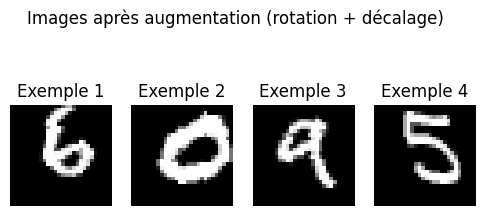

In [ ]:
# Cellule 5: Chargement de MNIST avec Data Augmentation
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.MNIST('./data', train=False, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"✅ MNIST chargé avec Data Augmentation")
print(f"Train: {len(train_dataset)} images")
print(f"Test: {len(test_dataset)} images")

# Visualisation
sample_image, sample_label = next(iter(train_loader))
plt.figure(figsize=(6,3))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(sample_image[i,0], cmap='gray')
    plt.title(f"Exemple {i+1}")
    plt.axis('off')
plt.suptitle("Images après augmentation (rotation + décalage)")
plt.show()

Entrainement du modele


In [ ]:
# Cellule 6: Entraînement avec Early Stopping (max 10 epochs)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5WithDropout().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_test_acc = 0
patience = 3
waiting = 0

print("🚀 Début de l'entraînement (max 10 epochs)")
print("-" * 50)

for epoch in range(10):      # ← changed from 20 to 10
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_acc = 100 * correct_test / total_test

    print(f"Epoch {epoch+1:2d}/10 - Loss: {running_loss/len(train_loader):.4f} - Train: {train_acc:.2f}% - Test: {test_acc:.2f}%")

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        waiting = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✅ Meilleur test: {best_test_acc:.2f}%")
    else:
        waiting += 1
        if waiting >= patience:
            print(f"\n🛑 Early stopping à l'epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best_model.pth'))
print(f"\n✅ Meilleure précision test: {best_test_acc:.2f}%")

🚀 Début de l'entraînement (max 10 epochs)
--------------------------------------------------
Epoch  1/10 - Loss: 0.7909 - Train: 74.06% - Test: 96.52%
  ✅ Meilleur test: 96.52%
Epoch  2/10 - Loss: 0.3354 - Train: 90.27% - Test: 97.55%
  ✅ Meilleur test: 97.55%
Epoch  3/10 - Loss: 0.2624 - Train: 92.63% - Test: 98.16%
  ✅ Meilleur test: 98.16%
Epoch  4/10 - Loss: 0.2245 - Train: 93.69% - Test: 98.28%
  ✅ Meilleur test: 98.28%
Epoch  5/10 - Loss: 0.1986 - Train: 94.44% - Test: 98.34%
  ✅ Meilleur test: 98.34%
Epoch  6/10 - Loss: 0.1848 - Train: 94.93% - Test: 98.47%
  ✅ Meilleur test: 98.47%
Epoch  7/10 - Loss: 0.1698 - Train: 95.35% - Test: 98.73%
  ✅ Meilleur test: 98.73%
Epoch  8/10 - Loss: 0.1588 - Train: 95.63% - Test: 98.78%
  ✅ Meilleur test: 98.78%
Epoch  9/10 - Loss: 0.1473 - Train: 95.98% - Test: 98.72%
Epoch 10/10 - Loss: 0.1410 - Train: 96.05% - Test: 98.85%
  ✅ Meilleur test: 98.85%

✅ Meilleure précision test: 98.85%


Evaluation sur le test set


In [ ]:
# Cellule 7: Évaluation du modèle
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Précision sur l'ensemble de test: {accuracy:.2f}%")
    return accuracy

evaluate(model, test_loader)

Précision sur l'ensemble de test: 98.85%


98.85

Visualisation des Feature Maps(Couche 1)


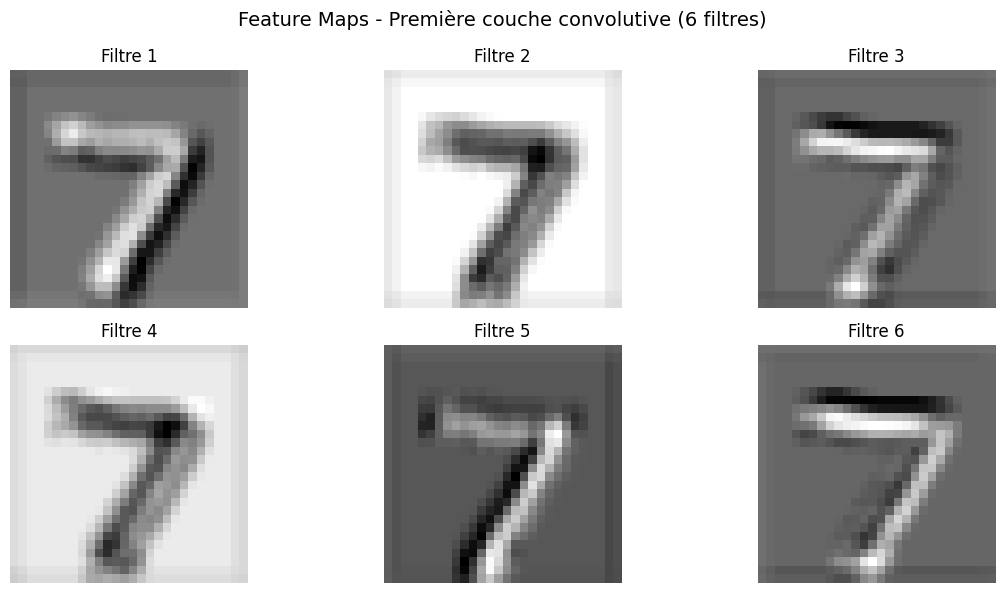

Objectif: Observer les motifs détectés par chaque filtre (bords, contours, etc.)


In [ ]:
# Cellule 8: Extraction et visualisation des feature maps - Première couche
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Enregistrement du hook sur la première couche convolutive
model.conv1.register_forward_hook(get_activation('conv1'))

# Récupération d'une image test
test_image, test_label = next(iter(test_loader))
test_image = test_image.to(device)

# Forward pass
model.eval()
with torch.no_grad():
    _ = model(test_image[0:1])

# Visualisation des 6 premiers feature maps
feature_maps = activation['conv1'][0]  # [6, 28, 28]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle('Feature Maps - Première couche convolutive (6 filtres)', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < 6:
        ax.imshow(feature_maps[i].cpu(), cmap='gray')
        ax.set_title(f'Filtre {i+1}')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("Objectif: Observer les motifs détectés par chaque filtre (bords, contours, etc.)")

Visualisation des Feature MAPS(Couche2)


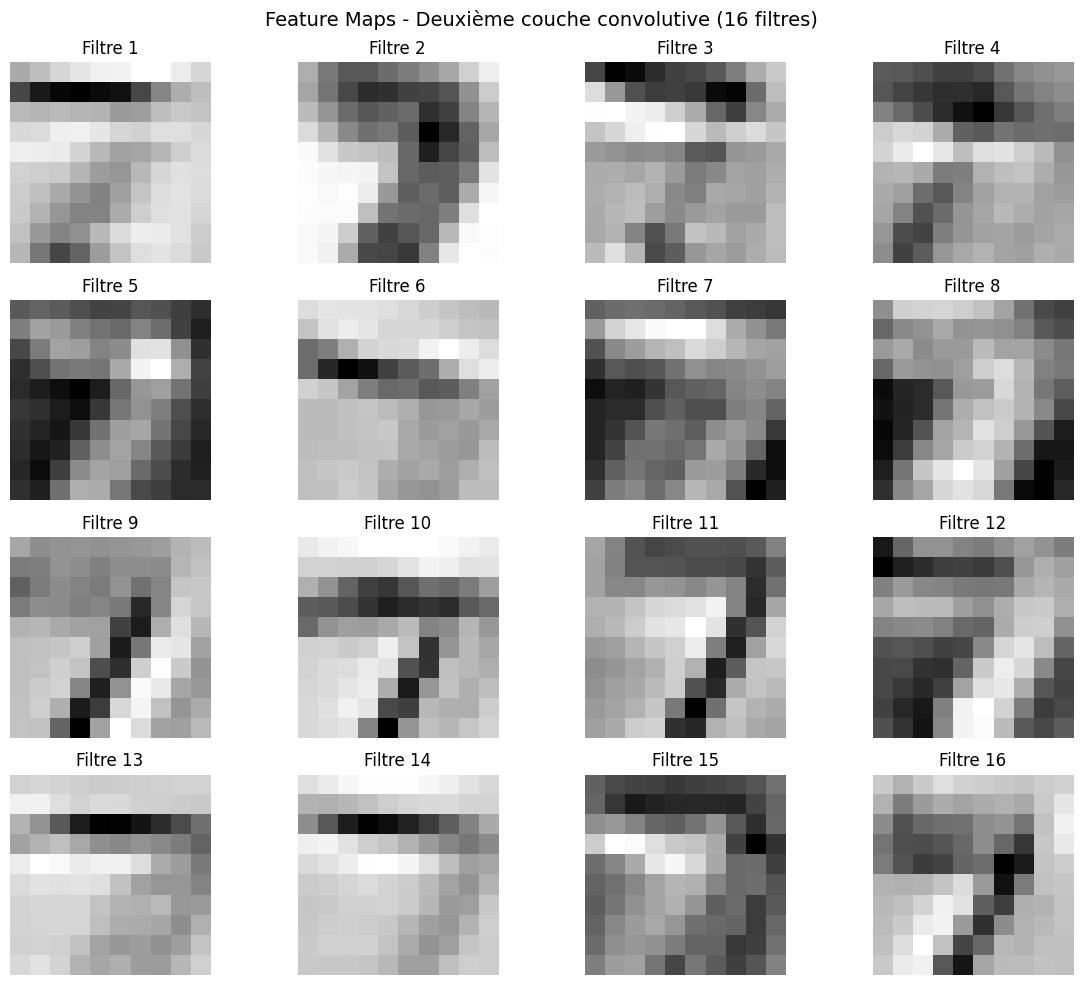

Objectif: Observer des motifs plus complexes après deux couches de convolution


In [ ]:
# Cellule 9: Visualisation des feature maps - Deuxième couche
model.conv2.register_forward_hook(get_activation('conv2'))

with torch.no_grad():
    _ = model(test_image[0:1])

feature_maps2 = activation['conv2'][0]  # [16, 10, 10]

# Affichage des 16 feature maps dans une grille 4x4
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
fig.suptitle('Feature Maps - Deuxième couche convolutive (16 filtres)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps2[i].cpu(), cmap='gray')
    ax.set_title(f'Filtre {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Objectif: Observer des motifs plus complexes après deux couches de convolution")

Comparaisons image originale vs feature maps


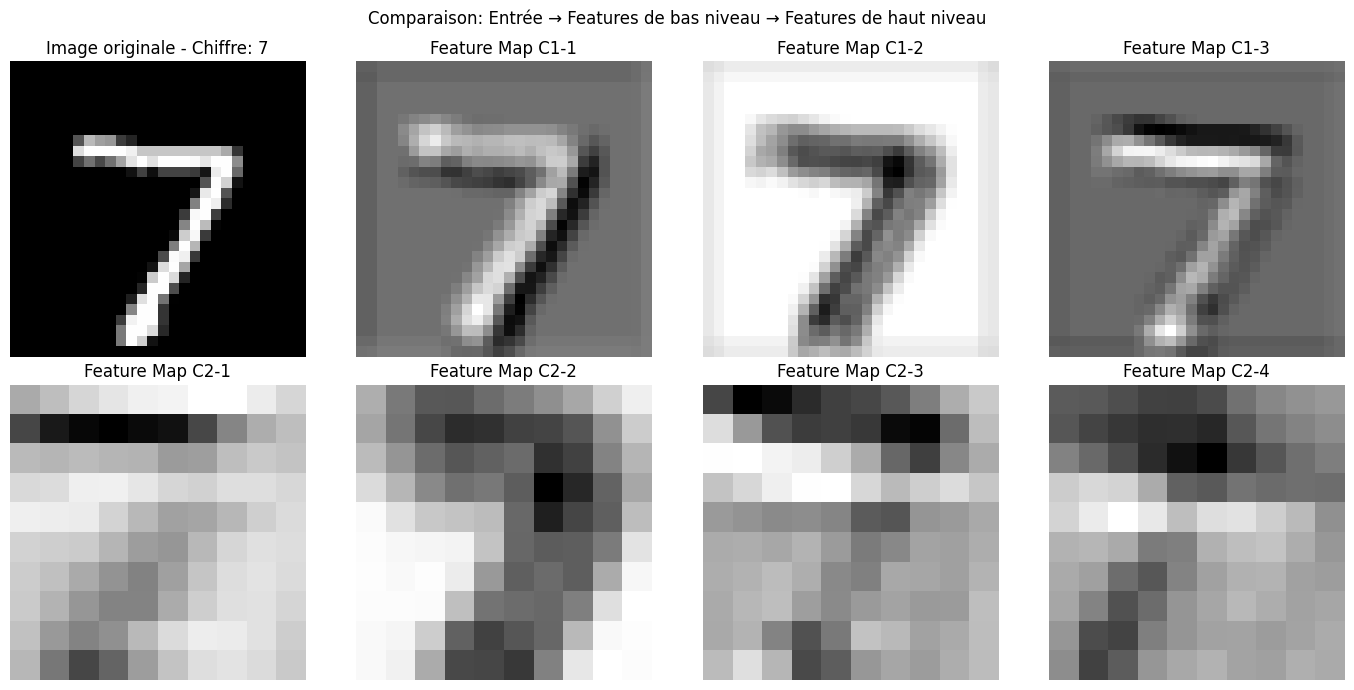

Résultat final: Le réseau a bien appris à extraire des caractéristiques discriminantes!


In [ ]:
# Cellule 10: Comparaison entre l'image originale et ses feature maps
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Image originale
axes[0,0].imshow(test_image[0,0].cpu(), cmap='gray')
axes[0,0].set_title(f'Image originale - Chiffre: {test_label[0].item()}')
axes[0,0].axis('off')

# 3 feature maps de la première couche
for i in range(3):
    axes[0, i+1].imshow(feature_maps[i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'Feature Map C1-{i+1}')
    axes[0, i+1].axis('off')

# 4 feature maps de la deuxième couche
for i in range(4):
    axes[1, i].imshow(feature_maps2[i].cpu(), cmap='gray')
    axes[1, i].set_title(f'Feature Map C2-{i+1}')
    axes[1, i].axis('off')

plt.suptitle('Comparaison: Entrée → Features de bas niveau → Features de haut niveau', fontsize=12)
plt.tight_layout()
plt.show()

print("Résultat final: Le réseau a bien appris à extraire des caractéristiques discriminantes!")